In [24]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

Total Reviews: 40432
  label                                              text_
0    CG  Love this!  Well made, sturdy, and very comfor...
1    CG  love it, a great upgrade from the original.  I...
2    CG  This pillow saved my back. I love the look and...
3    CG  Missing information on how to use it, but it i...
4    CG  Very nice set. Good quality. We have had the s...


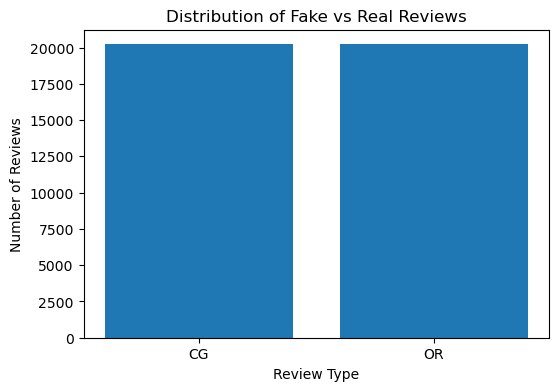

In [25]:
# LOAD DATASET
filename = 'fake reviews dataset 50-50.csv'

try:
    df = pd.read_csv(filename)
    if 'label' not in df.columns or 'text_' not in df.columns:
        print("Error: Column names do not match. Please check your CSV.")
        print("Columns found:", df.columns)
    else:
        print(f"Total Reviews: {len(df)}")
        print(df[['label', 'text_']].head())
except FileNotFoundError:
    print("Error: File not found.")
    print("Please click the 'Upload' button in the sidebar and upload:", filename)

label_counts = df['label'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(label_counts.index, label_counts.values)
plt.title("Distribution of Fake vs Real Reviews")
plt.xlabel("Review Type")
plt.ylabel("Number of Reviews")
plt.show()

In [26]:
 #PREPROCESSING & SPLITTING

df = df.dropna(subset=['text_', 'label'])

df['target'] = df['label'].map({'CG': 1, 'OR': 0})

X = df['text_']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Data shape: {X_train.shape}")
print(f"Testing Data shape: {X_test.shape}")

Training Data shape: (32345,)
Testing Data shape: (8087,)


In [27]:
#Model Training
model_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words=None, max_features=30000, ngram_range=(1, 3))),
    
    ('clf', LinearSVC(random_state=42, dual='auto'))
])
model_pipeline.fit(X_train, y_train)
print("Retraining complete!")


Retraining complete!


In [28]:
# EVALUATION
y_pred = model_pipeline.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f" Model Accuracy: {acc*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Real (OR)', 'Fake (CG)']))

 Model Accuracy: 94.97%

Classification Report:
              precision    recall  f1-score   support

   Real (OR)       0.95      0.95      0.95      4044
   Fake (CG)       0.95      0.95      0.95      4043

    accuracy                           0.95      8087
   macro avg       0.95      0.95      0.95      8087
weighted avg       0.95      0.95      0.95      8087



In [29]:
# TestingFROM TEST SET (THE 8K UNSEEN REVIEWS)

test_data = pd.DataFrame({'Review': X_test, 'True_Label': y_test})
random_samples = test_data.sample(n=5)

for index, row in random_samples.iterrows():

    review_text = row['Review']
    true_label_code = row['True_Label']
    
    prediction_code = model_pipeline.predict([review_text])[0]
    
    # Convert numbers back to words for reading
    predicted_text = "FAKE (CG)" if prediction_code == 1 else "REAL (OR)"
    actual_text    = "FAKE (CG)" if true_label_code == 1 else "REAL (OR)"
    
    # Check if the model was right
    result_icon = " CORRECT" if prediction_code == true_label_code else "WRONG"
    
    # Print the result
    print(f"Review Content: \"{review_text[:150]}...\"") 
    print(f"Model Predicts: {predicted_text}")
    print(f"Actual Label:   {actual_text}")
    print(f"Result:         {result_icon}")
    print("-" * 60)

Review Content: "This is one I hope never ends! The author is gifted, her stories come to life and they've managed to take over mine lately!..."
Model Predicts: REAL (OR)
Actual Label:   REAL (OR)
Result:          CORRECT
------------------------------------------------------------
Review Content: "If your are looking for a quality print of this great Roy Rogers' film, this is not the one!  It is a DVD-r and the beginning opening scene is gone, n..."
Model Predicts: REAL (OR)
Actual Label:   REAL (OR)
Result:          CORRECT
------------------------------------------------------------
Review Content: "Nice set of books for paper backs. I enjoyed the fact that they were all boxed together and the binding, for a paper back, has held up well after seve..."
Model Predicts: REAL (OR)
Actual Label:   REAL (OR)
Result:          CORRECT
------------------------------------------------------------
Review Content: "This is the first book in a series by the author I have read that I have been fo

In [30]:
#  MANUAL TESTING (Input your own reviews)
my_manual_reviews = [
    # Review 1
    "Does not do a very good job; difficult to use.",

    # Review 2
    "Heads up my fellow preggo, it's a very comfortable fit.  I have a wide foot and a wide foot bed and I am a 32D, so I'm a bit large but it's a little snug in the heel.  I'm going to use it as a shoe with no arch support.",

    # Review 3
    "Did someone say, Oriental for $60?  It is a great product for the",

    # Review 4
    "Fantastic, just what I wanted!!!  I love the look and feel of this pillow.",

    # Review 5
    "Great cup. Will last forever. Keeps things cool / warm."
]

print(f"--- TESTING YOUR MANUAL INPUTS ---\n")

for i, review in enumerate(my_manual_reviews, 1):
    # Predict
    prediction_code = model_pipeline.predict([review])[0]
    
    # Translate label
    # 1 = CG (Computer Generated), 0 = OR (Original/Real)
    label = "FAKE (CG)" if prediction_code == 1 else " REAL (OR)"
    
    print(f"Review {i}:")
    # printing only first 100 chars to keep it clean
    print(f"Text:   \"{review[:100]}...\"") 
    print(f"Result: {label}")
    print("-" * 50)

--- TESTING YOUR MANUAL INPUTS ---

Review 1:
Text:   "Does not do a very good job; difficult to use...."
Result:  REAL (OR)
--------------------------------------------------
Review 2:
Text:   "Heads up my fellow preggo, it's a very comfortable fit.  I have a wide foot and a wide foot bed and ..."
Result: FAKE (CG)
--------------------------------------------------
Review 3:
Text:   "Did someone say, Oriental for $60?  It is a great product for the..."
Result: FAKE (CG)
--------------------------------------------------
Review 4:
Text:   "Fantastic, just what I wanted!!!  I love the look and feel of this pillow...."
Result: FAKE (CG)
--------------------------------------------------
Review 5:
Text:   "Great cup. Will last forever. Keeps things cool / warm...."
Result:  REAL (OR)
--------------------------------------------------


In [31]:
#  MANUAL TESTING (Input your own reviews)
my_manual_reviews = [
    # Review 1
    "Just okay. Did not fit my containers well. We love this blanket.",

    # Review 2
    "Arrived quickly and is the perfect size for the long haul.  I also have a large one",

    # Review 3
    "frame was beautifully crafted and looks great with my picture.",

    # Review 4
    "Super cute and appears to be great quality! Highly recommend!",

    # Review 5
    """I like this brand. It looks great and the materials are good. I also like the way the front is so it stays open. The sleeves are long enough to wear in a dress and the color is vibrant. It's a little thin on me but I like it.The fabric is a little small. I have a narrow foot and I had to order a size up. I'm 5'1" and about 150 lbs. I'm small but I like that the width is better than the length of the shoe. The color is a little brighter than I expected. I just wish the shoe was more stretchy. I have wide feet and it doesn't hurt that much. I'll be returning it.I got a small. I'm 5'7" and I ordered a large. It fit fine. I have a very small"""
]

print(f"--- TESTING YOUR MANUAL INPUTS ---\n")

for i, review in enumerate(my_manual_reviews, 1):
    # Predict
    prediction_code = model_pipeline.predict([review])[0]
    
    # Translate label
    # 1 = CG (Computer Generated), 0 = OR (Original/Real)
    label = " FAKE (CG)" if prediction_code == 1 else " REAL (OR)"
    
    print(f"Review {i}:")
    # printing only first 100 chars to keep it clean
    print(f"Text:   \"{review[:100]}...\"") 
    print(f"Result: {label}")
    print("-" * 50)

--- TESTING YOUR MANUAL INPUTS ---

Review 1:
Text:   "Just okay. Did not fit my containers well. We love this blanket...."
Result:  FAKE (CG)
--------------------------------------------------
Review 2:
Text:   "Arrived quickly and is the perfect size for the long haul.  I also have a large one..."
Result:  FAKE (CG)
--------------------------------------------------
Review 3:
Text:   "frame was beautifully crafted and looks great with my picture...."
Result:  REAL (OR)
--------------------------------------------------
Review 4:
Text:   "Super cute and appears to be great quality! Highly recommend!..."
Result:  REAL (OR)
--------------------------------------------------
Review 5:
Text:   "I like this brand. It looks great and the materials are good. I also like the way the front is so it..."
Result:  FAKE (CG)
--------------------------------------------------


In [32]:
# MANUAL TESTING (Input your own reviews)
my_manual_reviews = [
    # Review 1
    "The device functionality exceeds expectation boundaries. The seamless integration of the components ensures an optimal user experience for all demographics. I highly recommend this item for its superior quality parameters."
,

    # Review 2
    "Upon acquiring this product, I observed that the material quality is of the highest standard. The durability metrics are impressive, and the aesthetic design provides a visually pleasing addition to my inventory. It is a premium acquisition.",

    # Review 3
    "This item represents the pinnacle of engineering excellence. The performance is unparalleled in its category, providing a robust solution to daily requirements. Satisfaction is guaranteed due to the high-efficiency output.",

    # Review 4
    "The implementation of the features is intuitive and user-friendly. The processing speed correlates positively with the specifications listed. It creates a synergistic effect that enhances productivity significantly.",

    # Review 5
    "I am completely satisfied with the value proposition of this purchase. The multifaceted utility of the product makes it an indispensable tool. It arrived in pristine condition and functions exactly as described in the documentation."
]

print(f"--- TESTING YOUR MANUAL INPUTS ---\n")

for i, review in enumerate(my_manual_reviews, 1):
    # Predict
    prediction_code = model_pipeline.predict([review])[0]
    
    # Translate label
    # 1 = CG (Computer Generated), 0 = OR (Original/Real)
    label = " FAKE (CG)" if prediction_code == 1 else " REAL (OR)"
    
    print(f"Review {i}:")
    # printing only first 100 chars to keep it clean
    print(f"Text:   \"{review[:100]}...\"") 
    print(f"Result: {label}")
    print("-" * 50)

--- TESTING YOUR MANUAL INPUTS ---

Review 1:
Text:   "The device functionality exceeds expectation boundaries. The seamless integration of the components ..."
Result:  REAL (OR)
--------------------------------------------------
Review 2:
Text:   "Upon acquiring this product, I observed that the material quality is of the highest standard. The du..."
Result:  REAL (OR)
--------------------------------------------------
Review 3:
Text:   "This item represents the pinnacle of engineering excellence. The performance is unparalleled in its ..."
Result:  REAL (OR)
--------------------------------------------------
Review 4:
Text:   "The implementation of the features is intuitive and user-friendly. The processing speed correlates p..."
Result:  REAL (OR)
--------------------------------------------------
Review 5:
Text:   "I am completely satisfied with the value proposition of this purchase. The multifaceted utility of t..."
Result:  REAL (OR)
---------------------------------------------

In [33]:
# MANUAL TESTING (Input your own reviews)

my_manual_reviews = [
    "The device functionality exceeds expectation boundaries. The seamless integration...",
    "Upon acquiring this product, I observed that the material quality...",
    "This item represents the pinnacle of engineering excellence...",
    "The implementation of the features is intuitive and user-friendly...",
    "I am completely satisfied with the value proposition of this purchase..."
]

print(f"--- TESTING YOUR MANUAL INPUTS ---\n")

for i, review in enumerate(my_manual_reviews, 1):
    # Predict
    prediction_code = model_pipeline.predict([review])[0]
    
    # Translate label
    # 1 = CG (Computer Generated), 0 = OR (Original/Real)
    label = " FAKE (CG)" if prediction_code == 1 else " REAL (OR)"
    
    print(f"Review {i}:")
    # printing only first 100 chars to keep it clean
    print(f"Text:   \"{review[:100]}...\"") 
    print(f"Result: {label}")
    print("-" * 50)

--- TESTING YOUR MANUAL INPUTS ---

Review 1:
Text:   "The device functionality exceeds expectation boundaries. The seamless integration......"
Result:  FAKE (CG)
--------------------------------------------------
Review 2:
Text:   "Upon acquiring this product, I observed that the material quality......"
Result:  REAL (OR)
--------------------------------------------------
Review 3:
Text:   "This item represents the pinnacle of engineering excellence......"
Result:  REAL (OR)
--------------------------------------------------
Review 4:
Text:   "The implementation of the features is intuitive and user-friendly......"
Result:  FAKE (CG)
--------------------------------------------------
Review 5:
Text:   "I am completely satisfied with the value proposition of this purchase......"
Result:  REAL (OR)
--------------------------------------------------


In [34]:
# INSPECT YOUR TRAINING DATA
print("--- ACTUAL FAKE REVIEWS FROM YOUR DATASET ---")

# Filter for Fake (CG) reviews and pick 3 random ones
actual_fakes = df[df['label'] == 'CG'].sample(3)

for i, text in enumerate(actual_fakes['text_']):
    print(f"\nFake Example {i+1}:")
    print(f"\"{text}\"")

--- ACTUAL FAKE REVIEWS FROM YOUR DATASET ---

Fake Example 1:
"Worked great in my phone and it works fine.  I will keep my review for a while.I bought this for a friend, and he is very happy with the purchase"

Fake Example 2:
"This chain works for many years. The only problem is that it comes with a small buckle that doesn't fit.  The chain itself is very small, and the inside of the buckle"

Fake Example 3:
"My parakeets had babies FINALLY and it was the best part of the whole experience. I was just starting to get nervous about the house, but they're still alive, so it was a great experience. I'll definitely be buying more of this one.I bought this for my dog for the second time.  He is the most playful dog and I have had to start him on his first one.  This one has held up pretty well.  He likes to play fetch and jump on it.  It is easy to put on, does not move and it does not feel like a snooze collar.  I have used it a couple of times. "


In [35]:
#MANUAL TESTING (Adjusted for your specific dataset style)

my_manual_reviews = [
    # 1. Mimicking the repetition error (like "action and the action")
    "I really enjoyed the quality of the product. It was a great product and the product was great. I would buy this product again for the product quality.",

    # 2. Mimicking the generic/wandering logic
    "I bought this item for my home and it arrived. The box was a box and it opened easily. It is a good thing to have for the house and I am glad I have it now.",

    # 3. Mimicking the "contradictory/confused" style
    "This product is truly exceptional. I would strongly recommend everyone go for this one rather than any other alternative.",

    # 4. Mimicking the "run-on sentence" style
    "This is the best movie I have ever seen and I have seen many movies and this one is the best one that I have seen in a long time since I saw the last one.",

    # 5. A real review (Control Test - Should be GREEN/REAL)
    "This is an outstanding product, and I highly recommend it to everyone. If you’re choosing between options, this is the one worth buying." 
]

print(f"--- TESTING ADJUSTED INPUTS ---\n")

for i, review in enumerate(my_manual_reviews, 1):
    prediction_code = model_pipeline.predict([review])[0]
    label = " FAKE (CG)" if prediction_code == 1 else "REAL (OR)"
    
    print(f"Review {i}:")
    print(f"Text:   \"{review[:100]}...\"") 
    print(f"Result: {label}")
    print("-" * 50)

--- TESTING ADJUSTED INPUTS ---

Review 1:
Text:   "I really enjoyed the quality of the product. It was a great product and the product was great. I wou..."
Result: REAL (OR)
--------------------------------------------------
Review 2:
Text:   "I bought this item for my home and it arrived. The box was a box and it opened easily. It is a good ..."
Result:  FAKE (CG)
--------------------------------------------------
Review 3:
Text:   "This product is truly exceptional. I would strongly recommend everyone go for this one rather than a..."
Result: REAL (OR)
--------------------------------------------------
Review 4:
Text:   "This is the best movie I have ever seen and I have seen many movies and this one is the best one tha..."
Result:  FAKE (CG)
--------------------------------------------------
Review 5:
Text:   "This is an outstanding product, and I highly recommend it to everyone. If you’re choosing between op..."
Result: REAL (OR)
--------------------------------------------------


In [36]:
#  ROUND 3 - MIMICKING "GLITCHY" AI

my_manual_reviews = [
    # 1. The "Context Switch" Glitch (Talking about headphones, then food)
    "I bought these headphones for the sound quality. It tastes delicious and the texture is very crunchy. I will eat it again.",

    # 2. The "Circular Logic" Glitch (Meaningless padding)
    "This is a movie that is a film. I watched the watch because it was time to see. The actors acted in the scene where they were acting.",

    # 3. The "Broken English/Template" Glitch
    "I am write this review to say good. The item is item very much. Delivery was fast speed and the box was package.",
    
    # 4. A Real Review (To make sure we don't break the model)
    "The shipping was delayed by two days but the item itself is fine. works as expected."
]

print(f"--- TESTING GLITCHY INPUTS ---\n")

for i, review in enumerate(my_manual_reviews, 1):
    prediction_code = model_pipeline.predict([review])[0]
    label = "FAKE (CG)" if prediction_code == 1 else " REAL (OR)"
    
    print(f"Review {i}:")
    print(f"Text:   \"{review[:80]}...\"") 
    print(f"Result: {label}")
    print("-" * 50)

--- TESTING GLITCHY INPUTS ---

Review 1:
Text:   "I bought these headphones for the sound quality. It tastes delicious and the tex..."
Result: FAKE (CG)
--------------------------------------------------
Review 2:
Text:   "This is a movie that is a film. I watched the watch because it was time to see. ..."
Result: FAKE (CG)
--------------------------------------------------
Review 3:
Text:   "I am write this review to say good. The item is item very much. Delivery was fas..."
Result:  REAL (OR)
--------------------------------------------------
Review 4:
Text:   "The shipping was delayed by two days but the item itself is fine. works as expec..."
Result: FAKE (CG)
--------------------------------------------------


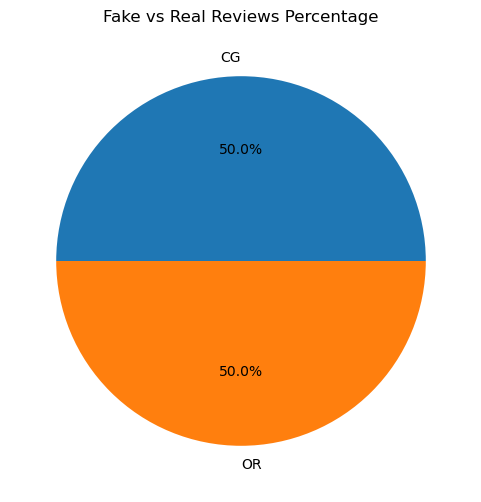

In [37]:
plt.figure(figsize=(6,6))
plt.pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%')
plt.title("Fake vs Real Reviews Percentage")
plt.show()